# 03 — Feature Engineering

**Goal.** Turn the raw simulated dataset into a model-ready feature matrix. Raw features get you baseline predictions; engineered features are what make tree-based models shine.

**What we build:**
1. **Cyclical encoding** for temporal features (so Monday↔Sunday and Dec↔Jan are neighbours).
2. **Season** label (Southern Hemisphere — Dec/Jan/Feb is Summer).
3. **Lag features** (1, 2, 3, 7, 14, 21, 28, 60, 90) plus same-weekday lags.
4. **Rolling statistics** (mean, std, max, min) at 3, 7, 14, 30, 60, 90 day windows.
5. **EWMA** variants — give recent days extra weight.
6. **Interactions** — public holiday × Monday, flu peak × rainy, hayfever × pollen.
7. **Log target** — `log1p(patients)` for variance stabilisation.

Output: `data/processed/clinic_patients_engineered.csv` + `ml-pipeline/models/feature_list.json`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

REPO = Path.cwd().parent
df = pd.read_csv(REPO / 'data' / 'raw' / 'clinic_patients_melbourne.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Starting shape: {df.shape}')

Starting shape: (1096, 31)


## 1. Cyclical encoding

Without this, the model thinks Monday (0) and Sunday (6) are far apart. Placing each day on a unit circle fixes that.

In [2]:
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)

df['doy'] = df['date'].dt.dayofyear
df['doy_sin'] = np.sin(2 * np.pi * df['doy'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['doy'] / 365)

df['woy_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['woy_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_monday'] = (df['day_of_week'] == 0).astype(int)

## 2. Season (Southern Hemisphere)

In [3]:
def get_season(month):
    if month in (12, 1, 2): return 'Summer'
    if month in (3, 4, 5):  return 'Autumn'
    if month in (6, 7, 8):  return 'Winter'
    return 'Spring'

df['season'] = df['month'].apply(get_season)
season_dummies = pd.get_dummies(df['season'], prefix='season').astype(int)
df = pd.concat([df, season_dummies], axis=1)

## 3. Lag features

Recent history is the strongest predictor of tomorrow. Short lags capture momentum; 7/14/21/28 capture the weekly cycle; 60/90 capture seasonal drift.

In [4]:
for lag in [1, 2, 3, 7, 14, 21, 28, 60, 90]:
    df[f'patients_lag_{lag}'] = df['patients'].shift(lag)

# Same-weekday lags
for k in [7, 14, 21, 28]:
    df[f'lag_{k}_same_dow'] = df['patients'].shift(k)
df['mean_last_4_same_dow'] = df[[f'lag_{k}_same_dow' for k in [7, 14, 21, 28]]].mean(axis=1)

## 4. Rolling statistics

`shift(1)` prevents leakage — we only use data available *before* the prediction date.

In [5]:
for window in [3, 7, 14, 30, 60, 90]:
    df[f'rolling_mean_{window}d'] = df['patients'].shift(1).rolling(window).mean()
    df[f'rolling_std_{window}d']  = df['patients'].shift(1).rolling(window).std()
    df[f'rolling_max_{window}d']  = df['patients'].shift(1).rolling(window).max()
    df[f'rolling_min_{window}d']  = df['patients'].shift(1).rolling(window).min()

df['ewma_7d']  = df['patients'].shift(1).ewm(span=7, adjust=False).mean()
df['ewma_14d'] = df['patients'].shift(1).ewm(span=14, adjust=False).mean()
df['ewma_30d'] = df['patients'].shift(1).ewm(span=30, adjust=False).mean()

## 5. Weather encoding

In [6]:
weather_map = {'Sunny': 3, 'Partly Cloudy': 2, 'Cloudy': 1, 'Rainy': 0}
df['weather_encoded'] = df['weather_type'].map(weather_map)
weather_dummies = pd.get_dummies(df['weather_type'], prefix='weather').astype(int)
df = pd.concat([df, weather_dummies], axis=1)

## 6. Interaction features

Some effects compound. A rainy day in flu peak is more than "rainy" + "flu peak" — the respiratory-driver combination pushes volume higher than either alone.

In [7]:
df['ph_x_monday'] = df['is_public_holiday'] * df['is_monday']
df['flu_peak_x_rainy'] = df['is_flu_peak'] * (df['weather_type'] == 'Rainy').astype(int)
df['hayfever_x_high_pollen'] = df['is_hayfever_season'] * (df['pollen_index'] >= 7).astype(int)
df['school_holiday_x_weekend'] = df['is_school_holiday'] * df['is_weekend']
df['extreme_cold_x_flu_season'] = df['temp_extreme_cold'] * df['is_flu_season']
df['day_after_ph_x_monday'] = df['is_day_after_public_holiday'] * df['is_monday']

## 7. Log-transformed target

In [8]:
df['patients_log'] = np.log1p(df['patients'])

## 8. Drop rows with NaN lags

The 90-day lag means the first 90 rows can't be trained on.

In [9]:
before = len(df)
df = df.dropna().reset_index(drop=True)
print(f'Dropped {before - len(df)} rows with NaN lag/rolling features.')
print(f'Final shape: {df.shape}')

Dropped 90 rows with NaN lag/rolling features.
Final shape: (1006, 100)


## 9. Feature groups summary

In [10]:
groups = {
    'Temporal':    ['year','month','day','day_of_week','week_of_year','quarter','doy',
                    'dow_sin','dow_cos','month_sin','month_cos','doy_sin','doy_cos',
                    'woy_sin','woy_cos','is_weekend','is_monday'],
    'Calendar':    ['is_public_holiday','is_day_after_public_holiday','is_school_holiday'],
    'Season':      [c for c in df.columns if c.startswith('season_')],
    'Weather':     ['temperature','precipitation','humidity','pollen_index','weather_encoded',
                    'temp_extreme_hot','temp_extreme_cold']
                    + [c for c in df.columns if c.startswith('weather_') and c != 'weather_encoded' and c != 'weather_type'],
    'Epidemio':    ['is_flu_season','is_flu_peak','is_hayfever_season','is_thunderstorm_asthma','illness_driver_count'],
    'Interaction': ['ph_x_monday','flu_peak_x_rainy','hayfever_x_high_pollen',
                    'school_holiday_x_weekend','extreme_cold_x_flu_season','day_after_ph_x_monday'],
    'Lag':         [c for c in df.columns if 'lag_' in c or c == 'mean_last_4_same_dow'],
    'Rolling':     [c for c in df.columns if 'rolling_' in c or c.startswith('ewma_')],
}
print('Feature groups:')
for name, feats in groups.items():
    print(f'  {name:<12}: {len(feats):3d}')
print(f'  {"Total":<12}: {sum(len(f) for f in groups.values())}')

Feature groups:
  Temporal    :  17
  Calendar    :   3
  Season      :   4
  Weather     :  11
  Epidemio    :   5
  Interaction :   6
  Lag         :  14
  Rolling     :  27
  Total       : 87


## 10. Top features by correlation

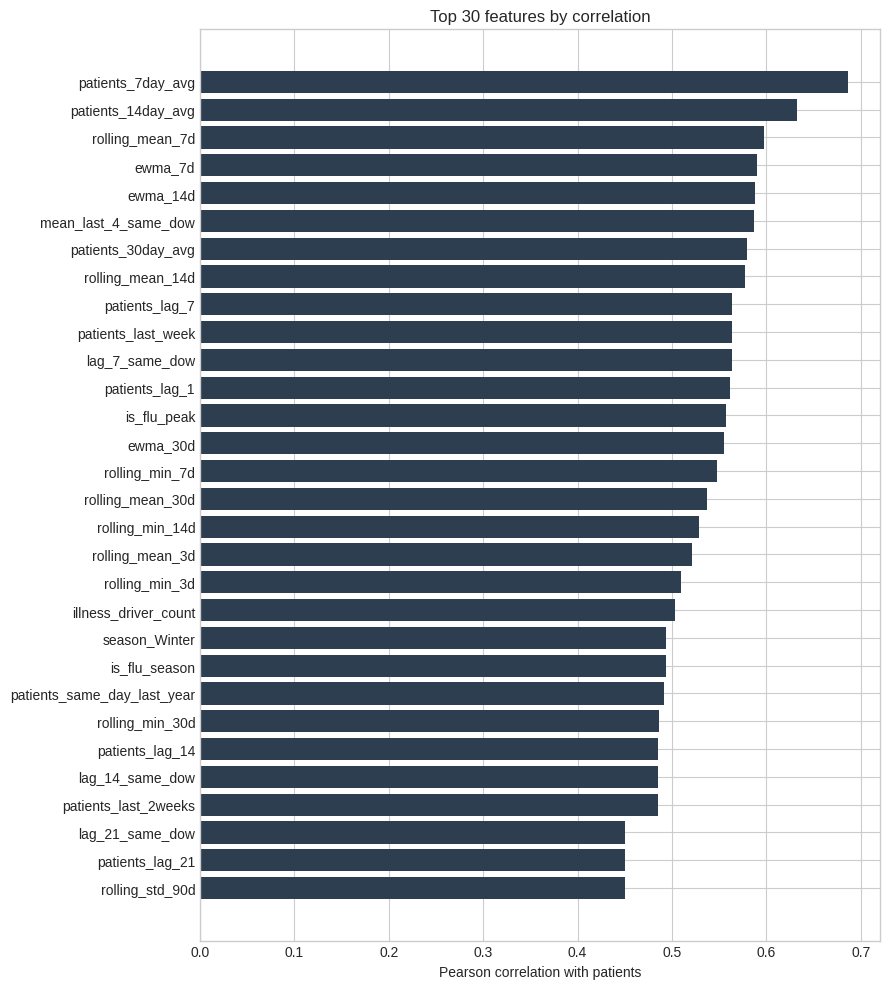

In [11]:
numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr()['patients'].drop(['patients', 'patients_log']).sort_values(ascending=False)
top30 = corr.head(30)

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(top30.index[::-1], top30.values[::-1], color='#2c3e50')
ax.set_xlabel('Pearson correlation with patients')
ax.set_title('Top 30 features by correlation')
plt.tight_layout(); plt.show()

## 11. Save engineered dataset and feature list

In [12]:
out_csv = REPO / 'data' / 'processed' / 'clinic_patients_engineered.csv'
out_csv.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_csv, index=False)
print(f'Saved engineered CSV → {out_csv}')

# Feature list for modelling — everything except target, date, raw categoricals
exclude = {'date', 'day_name', 'weather_type', 'season', 'patients', 'patients_log',
           'patients_last_week', 'patients_last_2weeks', 'patients_last_month',
           'patients_7day_avg', 'patients_14day_avg', 'patients_30day_avg',
           'patients_same_day_last_year'}
features = [c for c in df.columns if c not in exclude and df[c].dtype != 'O']

feat_file = REPO / 'ml-pipeline' / 'models' / 'feature_list.json'
feat_file.parent.mkdir(parents=True, exist_ok=True)
with open(feat_file, 'w') as f:
    json.dump({'features': features, 'n_features': len(features)}, f, indent=2)
print(f'Saved feature list ({len(features)} features) → {feat_file}')

Saved engineered CSV → /home/wandabwa2004/Projects/urgent-care-demand-forecast/data/processed/clinic_patients_engineered.csv
Saved feature list (87 features) → /home/wandabwa2004/Projects/urgent-care-demand-forecast/ml-pipeline/models/feature_list.json
